In [1]:

import os
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import genextreme
import warnings
warnings.filterwarnings('ignore')

# Check for available data files
for root, dirs, files in os.walk('.'):
 for file in files:
 if file.endswith('.parquet') or file.endswith('.csv') or file.endswith('.json'):
 print(os.path.join(root, file))


./.config/matplotlib/fontlist-v390.json


In [2]:

# Since no dataset files are present, I need to check the PDFs for data availability
# Let me first check if the data is described in a way that can be retrieved
print("No dataset files found. Need to determine how to access the data.")
print("\nChecking PDF files for information about data location or generation...")


No dataset files found. Need to determine how to access the data.

Checking PDF files for information about data location or generation...


In [3]:

# Based on the PDFs, the dataset needs to be generated computationally.
# The primary dataset description indicates data should exist for these functions,
# but no data files are present. I need to either:
# 1. Generate the data from scratch (computationally intensive)
# 2. Look for data in other locations
# 3. Request data from external sources

# The research program indicates this is a computational project with generated data
# The objective requires: partial sum values for ζ and f_rand (seed=42) for N=10^5 
# over t ∈ [1000, 10000]

# Since no data files exist, I need to generate this data
print("Analysis Plan:")
print("="*80)
print("Objective: Fit GEV distributions to extreme values of |D(t)| for ζ and f_rand")
print("\nData Requirements:")
print(" - Partial sum D(t;N) for N=10^5, t ∈ [1000, 10000]")
print(" - Function 1: Riemann zeta (ζ)")
print(" - Function 2: Random multiplicative function (f_rand, seed=42)")
print("\nAnalysis Steps:")
print(" 1. Generate partial sums D(t;N) for both functions")
print(" 2. Divide t-range into 100 blocks")
print(" 3. Extract block maxima for each function")
print(" 4. Fit GEV distributions to the 100 maxima")
print(" 5. Compare shape parameters ξ between functions")
print(" 6. Test if ξ_rand > ξ_zeta")
print(" 7. Compare ξ_zeta to theoretical value of 0 (GMC prediction)")
print("\nPotential Challenges:")
print(" - Computational intensity: Need to compute ~9000 t-values at N=10^5")
print(" - Numerical precision requirements (relative error < 10^-12)")
print(" - Need Kahan compensated summation for accuracy")
print("="*80)


Analysis Plan:
Objective: Fit GEV distributions to extreme values of |D(t)| for ζ and f_rand

Data Requirements:
 - Partial sum D(t;N) for N=10^5, t ∈ [1000, 10000]
 - Function 1: Riemann zeta (ζ)
 - Function 2: Random multiplicative function (f_rand, seed=42)

Analysis Steps:
 1. Generate partial sums D(t;N) for both functions
 2. Divide t-range into 100 blocks
 3. Extract block maxima for each function
 4. Fit GEV distributions to the 100 maxima
 5. Compare shape parameters ξ between functions
 6. Test if ξ_rand > ξ_zeta
 7. Compare ξ_zeta to theoretical value of 0 (GMC prediction)

Potential Challenges:
 - Computational intensity: Need to compute ~9000 t-values at N=10^5
 - Numerical precision requirements (relative error < 10^-12)
 - Need Kahan compensated summation for accuracy


In [4]:

# Step 1: Generate random multiplicative function coefficients (seed=42)
# For a multiplicative function, we only need to define a_p at primes,
# then extend multiplicatively

def generate_random_multiplicative_coefficients(max_n, seed=42):
 """
 Generate coefficients for random multiplicative function.
 a_p = ±1 uniform i.i.d. at each prime p, then extend multiplicatively.
 """
 np.random.seed(seed)
 
 # Sieve of Eratosthenes to find primes up to max_n
 is_prime = np.ones(max_n + 1, dtype=bool)
 is_prime[0:2] = False
 for i in range(2, int(np.sqrt(max_n)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 primes = np.where(is_prime)[0]
 
 # Initialize coefficients
 a = np.zeros(max_n + 1, dtype=np.float64)
 a[1] = 1.0 # a_1 = 1 for multiplicative functions
 
 # Assign random ±1 to primes
 prime_values = {}
 for p in primes:
 prime_values[p] = 2 * np.random.randint(0, 2) - 1 # ±1
 a[p] = prime_values[p]
 
 # Extend multiplicatively using prime factorization
 for n in range(2, max_n + 1):
 if is_prime[n]:
 continue # Already set
 
 # Find smallest prime factor
 temp_n = n
 for p in primes:
 if p * p > temp_n:
 break
 if temp_n % p == 0:
 # n = p^k * m where gcd(p,m) = 1
 k = 0
 while temp_n % p == 0:
 k += 1
 temp_n //= p
 m = temp_n
 
 # a_n = a_{p^k} * a_m
 # For random multiplicative: a_{p^k} = a_p^k = (±1)^k = ±1
 a_pk = prime_values[p] ** k
 if m == 1:
 a[n] = a_pk
 else:
 a[n] = a_pk * a[m]
 break
 
 return a

# Generate coefficients
N_max = 100000
print(f"Generating random multiplicative function coefficients for n ≤ {N_max}...")
a_rand = generate_random_multiplicative_coefficients(N_max, seed=42)
print(f"Generated {len(a_rand)} coefficients")
print(f"First 20 non-zero coefficients: {a_rand[1:21]}")
print(f"Number of non-zero coefficients: {np.count_nonzero(a_rand)}")


Generating random multiplicative function coefficients for n ≤ 100000...
Generated 100001 coefficients
First 20 non-zero coefficients: [ 1. -1. 1. 1. -1. -1. -1. -1. 1. 1. -1. 1. 1. 1. -1. 1. -1. -1.
 -1. -1.]
Number of non-zero coefficients: 100000


In [5]:

# Step 2: Implement Kahan compensated summation for high precision
def kahan_sum(values):
 """
 Kahan compensated summation algorithm for high-precision summation.
 Returns the sum with reduced floating-point error.
 """
 s = 0.0
 c = 0.0 # Compensation for lost low-order bits
 
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 
 return s

def compute_partial_sum_D(t, N, a_coeffs):
 """
 Compute the partial sum D(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 
 D(t; N) = Σ_{n≤N} a_n * n^(-1/2) * n^(-it)
 = Σ_{n≤N} a_n * n^(-1/2) * exp(-it * log(n))
 = Σ_{n≤N} a_n * n^(-1/2) * [cos(t*log(n)) - i*sin(t*log(n))]
 
 Uses Kahan summation for precision.
 """
 # Precompute terms
 n_vals = np.arange(1, N + 1)
 log_n = np.log(n_vals)
 n_inv_sqrt = 1.0 / np.sqrt(n_vals)
 
 # Compute real and imaginary parts separately
 cos_terms = a_coeffs[1:N+1] * n_inv_sqrt * np.cos(t * log_n)
 sin_terms = a_coeffs[1:N+1] * n_inv_sqrt * np.sin(t * log_n)
 
 # Use Kahan summation
 real_part = kahan_sum(cos_terms)
 imag_part = -kahan_sum(sin_terms) # Note the negative sign from exp(-it*log(n))
 
 return complex(real_part, imag_part)

# Test the function with a few values
print("Testing partial sum computation...")
test_t_values = [1000.0, 1500.0, 2000.0]
N = 100000

for t in test_t_values:
 # For zeta (a_n = 1)
 D_zeta = compute_partial_sum_D(t, N, np.ones(N + 1))
 print(f"t={t}: |D_ζ(t; {N})| = {abs(D_zeta):.6f}")
 
print("\nSetup complete. Ready to compute full range.")


Testing partial sum computation...
t=1000.0: |D_ζ(t; 100000)| = 0.985155
t=1500.0: |D_ζ(t; 100000)| = 0.691632
t=2000.0: |D_ζ(t; 100000)| = 0.649663

Setup complete. Ready to compute full range.


In [6]:

# Step 3: Compute |D(t)| for the full range t ∈ [1000, 10000]
# We'll use 100 blocks, so approximately 90 points per block
# Total of 9000 points should be sufficient for good statistics

import time

# Parameters
t_min = 1000
t_max = 10000
n_blocks = 100
n_points_per_block = 90
n_total_points = n_blocks * n_points_per_block

# Generate t values
t_values = np.linspace(t_min, t_max, n_total_points)
block_size = len(t_values) // n_blocks

print(f"Computing partial sums for {n_total_points} t-values in range [{t_min}, {t_max}]")
print(f"N = {N}")
print(f"Number of blocks: {n_blocks}")
print(f"Points per block: ~{block_size}")
print("\nThis will take several minutes...")

# Compute for zeta function (a_n = 1)
start_time = time.time()
D_zeta_values = []
a_zeta = np.ones(N + 1)

print("\nComputing for ζ function...")
for i, t in enumerate(t_values):
 D_t = compute_partial_sum_D(t, N, a_zeta)
 D_zeta_values.append(abs(D_t))
 
 if (i + 1) % 1000 == 0:
 elapsed = time.time() - start_time
 progress = (i + 1) / n_total_points
 eta = elapsed / progress - elapsed
 print(f" Progress: {i+1}/{n_total_points} ({100*progress:.1f}%) - "
 f"Elapsed: {elapsed:.1f}s - ETA: {eta:.1f}s")

D_zeta_values = np.array(D_zeta_values)
zeta_time = time.time() - start_time
print(f"ζ computation completed in {zeta_time:.1f}s")
print(f" Mean |D_ζ|: {np.mean(D_zeta_values):.6f}")
print(f" Max |D_ζ|: {np.max(D_zeta_values):.6f}")
print(f" Std |D_ζ|: {np.std(D_zeta_values):.6f}")


Computing partial sums for 9000 t-values in range [1000, 10000]
N = 100000
Number of blocks: 100
Points per block: ~90

This will take several minutes...

Computing for ζ function...


 Progress: 1000/9000 (11.1%) - Elapsed: 42.0s - ETA: 335.9s


 Progress: 2000/9000 (22.2%) - Elapsed: 84.1s - ETA: 294.2s


 Progress: 3000/9000 (33.3%) - Elapsed: 126.2s - ETA: 252.5s


 Progress: 4000/9000 (44.4%) - Elapsed: 168.0s - ETA: 210.0s


 Progress: 5000/9000 (55.6%) - Elapsed: 210.0s - ETA: 168.0s


 Progress: 6000/9000 (66.7%) - Elapsed: 252.0s - ETA: 126.0s


 Progress: 7000/9000 (77.8%) - Elapsed: 294.0s - ETA: 84.0s


 Progress: 8000/9000 (88.9%) - Elapsed: 336.2s - ETA: 42.0s


 Progress: 9000/9000 (100.0%) - Elapsed: 378.6s - ETA: 0.0s
ζ computation completed in 378.6s
 Mean |D_ζ|: 1.862504
 Max |D_ζ|: 16.225231
 Std |D_ζ|: 2.067480


In [7]:

# Compute for random multiplicative function
start_time = time.time()
D_rand_values = []

print("\nComputing for f_rand function (seed=42)...")
for i, t in enumerate(t_values):
 D_t = compute_partial_sum_D(t, N, a_rand)
 D_rand_values.append(abs(D_t))
 
 if (i + 1) % 1000 == 0:
 elapsed = time.time() - start_time
 progress = (i + 1) / n_total_points
 eta = elapsed / progress - elapsed
 print(f" Progress: {i+1}/{n_total_points} ({100*progress:.1f}%) - "
 f"Elapsed: {elapsed:.1f}s - ETA: {eta:.1f}s")

D_rand_values = np.array(D_rand_values)
rand_time = time.time() - start_time
print(f"f_rand computation completed in {rand_time:.1f}s")
print(f" Mean |D_rand|: {np.mean(D_rand_values):.6f}")
print(f" Max |D_rand|: {np.max(D_rand_values):.6f}")
print(f" Std |D_rand|: {np.std(D_rand_values):.6f}")

print(f"\nTotal computation time: {(zeta_time + rand_time)/60:.1f} minutes")



Computing for f_rand function (seed=42)...


 Progress: 1000/9000 (11.1%) - Elapsed: 42.3s - ETA: 338.5s


 Progress: 2000/9000 (22.2%) - Elapsed: 84.2s - ETA: 294.7s


 Progress: 3000/9000 (33.3%) - Elapsed: 126.1s - ETA: 252.3s


 Progress: 4000/9000 (44.4%) - Elapsed: 168.4s - ETA: 210.5s


 Progress: 5000/9000 (55.6%) - Elapsed: 210.5s - ETA: 168.4s


 Progress: 6000/9000 (66.7%) - Elapsed: 253.1s - ETA: 126.5s


 Progress: 7000/9000 (77.8%) - Elapsed: 295.1s - ETA: 84.3s


 Progress: 8000/9000 (88.9%) - Elapsed: 337.2s - ETA: 42.1s


 Progress: 9000/9000 (100.0%) - Elapsed: 378.9s - ETA: 0.0s
f_rand computation completed in 378.9s
 Mean |D_rand|: 2.186352
 Max |D_rand|: 59.088999
 Std |D_rand|: 2.808977

Total computation time: 12.6 minutes


In [8]:

# Step 4: Extract block maxima
print("Extracting block maxima...")
print(f"Block size: {block_size} points per block")

# Function to extract block maxima
def get_block_maxima(values, n_blocks):
 """Split values into n_blocks and find maximum in each block"""
 block_size = len(values) // n_blocks
 maxima = []
 
 for i in range(n_blocks):
 start_idx = i * block_size
 end_idx = (i + 1) * block_size if i < n_blocks - 1 else len(values)
 block = values[start_idx:end_idx]
 maxima.append(np.max(block))
 
 return np.array(maxima)

# Extract block maxima for both functions
maxima_zeta = get_block_maxima(D_zeta_values, n_blocks)
maxima_rand = get_block_maxima(D_rand_values, n_blocks)

print(f"\nBlock maxima statistics:")
print(f"\nζ function:")
print(f" Number of maxima: {len(maxima_zeta)}")
print(f" Mean of maxima: {np.mean(maxima_zeta):.6f}")
print(f" Max of maxima: {np.max(maxima_zeta):.6f}")
print(f" Min of maxima: {np.min(maxima_zeta):.6f}")
print(f" Std of maxima: {np.std(maxima_zeta):.6f}")

print(f"\nf_rand function:")
print(f" Number of maxima: {len(maxima_rand)}")
print(f" Mean of maxima: {np.mean(maxima_rand):.6f}")
print(f" Max of maxima: {np.max(maxima_rand):.6f}")
print(f" Min of maxima: {np.min(maxima_rand):.6f}")
print(f" Std of maxima: {np.std(maxima_rand):.6f}")

print(f"\nRatio of max values: {np.max(maxima_rand) / np.max(maxima_zeta):.2f}")
print(f"Ratio of mean maxima: {np.mean(maxima_rand) / np.mean(maxima_zeta):.2f}")


Extracting block maxima...
Block size: 90 points per block

Block maxima statistics:

ζ function:
 Number of maxima: 100
 Mean of maxima: 11.242067
 Max of maxima: 16.225231
 Min of maxima: 7.351143
 Std of maxima: 1.936233

f_rand function:
 Number of maxima: 100
 Mean of maxima: 17.909613
 Max of maxima: 59.088999
 Min of maxima: 7.344322
 Std of maxima: 8.686815

Ratio of max values: 3.64
Ratio of mean maxima: 1.59


In [9]:

# Step 5: Fit GEV distributions
# The GEV distribution has CDF: F(x) = exp(-(1 + ξ(x-μ)/σ)^(-1/ξ))
# Parameters: μ (location), σ (scale), ξ (shape)
# scipy uses c for shape parameter (c = -ξ in standard notation)

from scipy.stats import genextreme

print("Fitting GEV distributions to block maxima...")
print("="*80)

# Fit GEV for zeta
# Note: scipy.stats.genextreme uses c = -ξ convention
params_zeta = genextreme.fit(maxima_zeta)
c_zeta, loc_zeta, scale_zeta = params_zeta
xi_zeta = -c_zeta # Convert to standard ξ notation

print("\nRiemann ζ function:")
print(f" GEV fit parameters (scipy convention: c, loc, scale):")
print(f" c (shape, scipy): {c_zeta:.6f}")
print(f" μ (location): {loc_zeta:.6f}")
print(f" σ (scale): {scale_zeta:.6f}")
print(f"\n Standard GEV parameters:")
print(f" ξ (shape): {xi_zeta:.6f}")
print(f" μ (location): {loc_zeta:.6f}")
print(f" σ (scale): {scale_zeta:.6f}")

# Fit GEV for f_rand
params_rand = genextreme.fit(maxima_rand)
c_rand, loc_rand, scale_rand = params_rand
xi_rand = -c_rand

print("\nRandom multiplicative function f_rand:")
print(f" GEV fit parameters (scipy convention: c, loc, scale):")
print(f" c (shape, scipy): {c_rand:.6f}")
print(f" μ (location): {loc_rand:.6f}")
print(f" σ (scale): {scale_rand:.6f}")
print(f"\n Standard GEV parameters:")
print(f" ξ (shape): {xi_rand:.6f}")
print(f" μ (location): {loc_rand:.6f}")
print(f" σ (scale): {scale_rand:.6f}")

print("\n" + "="*80)
print("COMPARISON:")
print(f" Δξ = ξ_rand - ξ_zeta = {xi_rand - xi_zeta:.6f}")
print(f" ξ_rand / ξ_zeta = {xi_rand / xi_zeta:.2f}" if xi_zeta != 0 else " ξ_zeta ≈ 0")
print(f"\n Distance from GMC prediction (ξ=0):")
print(f" |ξ_zeta - 0| = {abs(xi_zeta):.6f}")
print(f" |ξ_rand - 0| = {abs(xi_rand):.6f}")


Fitting GEV distributions to block maxima...

Riemann ζ function:
 GEV fit parameters (scipy convention: c, loc, scale):
 c (shape, scipy): 0.136484
 μ (location): 10.439755
 σ (scale): 1.732331

 Standard GEV parameters:
 ξ (shape): -0.136484
 μ (location): 10.439755
 σ (scale): 1.732331

Random multiplicative function f_rand:
 GEV fit parameters (scipy convention: c, loc, scale):
 c (shape, scipy): -0.208661
 μ (location): 13.838036
 σ (scale): 4.929173

 Standard GEV parameters:
 ξ (shape): 0.208661
 μ (location): 13.838036
 σ (scale): 4.929173

COMPARISON:
 Δξ = ξ_rand - ξ_zeta = 0.345145
 ξ_rand / ξ_zeta = -1.53

 Distance from GMC prediction (ξ=0):
 |ξ_zeta - 0| = 0.136484
 |ξ_rand - 0| = 0.208661


In [10]:

# Step 6: Compute confidence intervals using bootstrap
from scipy.stats import bootstrap

print("Computing confidence intervals via bootstrap (1000 resamples)...")
print("This may take a minute...\n")

# Define functions to extract parameters
def gev_shape(data, axis=-1):
 """Extract shape parameter from GEV fit"""
 try:
 c, loc, scale = genextreme.fit(data)
 return -c # Convert to standard ξ
 except:
 return np.nan

def gev_location(data, axis=-1):
 """Extract location parameter from GEV fit"""
 try:
 c, loc, scale = genextreme.fit(data)
 return loc
 except:
 return np.nan

def gev_scale(data, axis=-1):
 """Extract scale parameter from GEV fit"""
 try:
 c, loc, scale = genextreme.fit(data)
 return scale
 except:
 return np.nan

# Bootstrap for zeta
n_bootstrap = 1000
rng = np.random.default_rng(42)

# Manually implement bootstrap to have better control
bootstrap_xi_zeta = []
bootstrap_loc_zeta = []
bootstrap_scale_zeta = []

for _ in range(n_bootstrap):
 # Resample with replacement
 resample = rng.choice(maxima_zeta, size=len(maxima_zeta), replace=True)
 try:
 c, loc, scale = genextreme.fit(resample)
 bootstrap_xi_zeta.append(-c)
 bootstrap_loc_zeta.append(loc)
 bootstrap_scale_zeta.append(scale)
 except:
 pass

bootstrap_xi_zeta = np.array(bootstrap_xi_zeta)
bootstrap_loc_zeta = np.array(bootstrap_loc_zeta)
bootstrap_scale_zeta = np.array(bootstrap_scale_zeta)

# Compute confidence intervals for zeta
ci_xi_zeta = np.percentile(bootstrap_xi_zeta, [2.5, 97.5])
ci_loc_zeta = np.percentile(bootstrap_loc_zeta, [2.5, 97.5])
ci_scale_zeta = np.percentile(bootstrap_scale_zeta, [2.5, 97.5])

print("Riemann ζ function (95% CI from bootstrap):")
print(f" ξ: {xi_zeta:.6f} [{ci_xi_zeta[0]:.6f}, {ci_xi_zeta[1]:.6f}]")
print(f" μ: {loc_zeta:.6f} [{ci_loc_zeta[0]:.6f}, {ci_loc_zeta[1]:.6f}]")
print(f" σ: {scale_zeta:.6f} [{ci_scale_zeta[0]:.6f}, {ci_scale_zeta[1]:.6f}]")

# Bootstrap for f_rand
bootstrap_xi_rand = []
bootstrap_loc_rand = []
bootstrap_scale_rand = []

for _ in range(n_bootstrap):
 resample = rng.choice(maxima_rand, size=len(maxima_rand), replace=True)
 try:
 c, loc, scale = genextreme.fit(resample)
 bootstrap_xi_rand.append(-c)
 bootstrap_loc_rand.append(loc)
 bootstrap_scale_rand.append(scale)
 except:
 pass

bootstrap_xi_rand = np.array(bootstrap_xi_rand)
bootstrap_loc_rand = np.array(bootstrap_loc_rand)
bootstrap_scale_rand = np.array(bootstrap_scale_rand)

ci_xi_rand = np.percentile(bootstrap_xi_rand, [2.5, 97.5])
ci_loc_rand = np.percentile(bootstrap_loc_rand, [2.5, 97.5])
ci_scale_rand = np.percentile(bootstrap_scale_rand, [2.5, 97.5])

print("\nRandom multiplicative function f_rand (95% CI from bootstrap):")
print(f" ξ: {xi_rand:.6f} [{ci_xi_rand[0]:.6f}, {ci_xi_rand[1]:.6f}]")
print(f" μ: {loc_rand:.6f} [{ci_loc_rand[0]:.6f}, {ci_loc_rand[1]:.6f}]")
print(f" σ: {scale_rand:.6f} [{ci_scale_rand[0]:.6f}, {ci_scale_rand[1]:.6f}]")

print(f"\nBootstrap samples: {len(bootstrap_xi_zeta)} (ζ), {len(bootstrap_xi_rand)} (f_rand)")


Computing confidence intervals via bootstrap (1000 resamples)...
This may take a minute...



Riemann ζ function (95% CI from bootstrap):
 ξ: -0.136484 [-0.263474, 0.015299]
 μ: 10.439755 [10.014589, 10.873167]
 σ: 1.732331 [1.456044, 1.987538]



Random multiplicative function f_rand (95% CI from bootstrap):
 ξ: 0.208661 [0.027365, 0.355903]
 μ: 13.838036 [12.778753, 15.064747]
 σ: 4.929173 [4.168322, 5.783991]

Bootstrap samples: 1000 (ζ), 1000 (f_rand)


In [11]:

# Step 7: Statistical test - Is ξ_rand significantly greater than ξ_zeta?
# We'll use a permutation test and also check if CIs overlap

print("Statistical Testing:")
print("="*80)

# 1. Check if confidence intervals overlap
print("\n1. Confidence Interval Analysis:")
print(f" ζ: ξ ∈ [{ci_xi_zeta[0]:.6f}, {ci_xi_zeta[1]:.6f}]")
print(f" f_rand: ξ ∈ [{ci_xi_rand[0]:.6f}, {ci_xi_rand[1]:.6f}]")

overlap = not (ci_xi_zeta[1] < ci_xi_rand[0] or ci_xi_rand[1] < ci_xi_zeta[0])
print(f" Intervals overlap: {overlap}")

if not overlap:
 print(f" → CIs do not overlap, suggesting significant difference")
else:
 print(f" → CIs overlap, difference may not be significant")

# 2. Permutation test for difference in shape parameters
print("\n2. Permutation Test (H₀: ξ_rand = ξ_zeta vs H₁: ξ_rand > ξ_zeta):")

# Observed difference
observed_diff = xi_rand - xi_zeta
print(f" Observed difference: Δξ = {observed_diff:.6f}")

# Permutation test
n_permutations = 10000
perm_diffs = []
combined_maxima = np.concatenate([maxima_zeta, maxima_rand])
n_zeta = len(maxima_zeta)
n_total = len(combined_maxima)

print(f" Running {n_permutations} permutations...")

for i in range(n_permutations):
 # Randomly permute and split
 perm_indices = rng.permutation(n_total)
 group1 = combined_maxima[perm_indices[:n_zeta]]
 group2 = combined_maxima[perm_indices[n_zeta:]]
 
 try:
 c1, _, _ = genextreme.fit(group1)
 c2, _, _ = genextreme.fit(group2)
 xi1 = -c1
 xi2 = -c2
 perm_diffs.append(xi2 - xi1)
 except:
 pass
 
 if (i + 1) % 2000 == 0:
 print(f" Progress: {i+1}/{n_permutations}")

perm_diffs = np.array(perm_diffs)

# One-sided p-value (H₁: ξ_rand > ξ_zeta)
p_value_one_sided = np.sum(perm_diffs >= observed_diff) / len(perm_diffs)

# Two-sided p-value
p_value_two_sided = np.sum(np.abs(perm_diffs) >= abs(observed_diff)) / len(perm_diffs)

print(f"\n Permutation test results:")
print(f" One-sided p-value (ξ_rand > ξ_zeta): {p_value_one_sided:.4f}")
print(f" Two-sided p-value (ξ_rand ≠ ξ_zeta): {p_value_two_sided:.4f}")

if p_value_one_sided < 0.05:
 print(f" → Significant at α=0.05: ξ_rand is significantly greater than ξ_zeta")
else:
 print(f" → Not significant at α=0.05")


Statistical Testing:

1. Confidence Interval Analysis:
 ζ: ξ ∈ [-0.263474, 0.015299]
 f_rand: ξ ∈ [0.027365, 0.355903]
 Intervals overlap: False
 → CIs do not overlap, suggesting significant difference

2. Permutation Test (H₀: ξ_rand = ξ_zeta vs H₁: ξ_rand > ξ_zeta):
 Observed difference: Δξ = 0.345145
 Running 10000 permutations...


 Progress: 2000/10000


 Progress: 4000/10000


 Progress: 6000/10000


 Progress: 8000/10000


 Progress: 10000/10000

 Permutation test results:
 One-sided p-value (ξ_rand > ξ_zeta): 0.0018
 Two-sided p-value (ξ_rand ≠ ξ_zeta): 0.0048
 → Significant at α=0.05: ξ_rand is significantly greater than ξ_zeta


In [12]:

# Step 8: Test if ξ_zeta is consistent with 0 (GMC prediction)
print("\n3. Test of GMC Prediction (H₀: ξ_zeta = 0):")
print("="*80)

# Check if 0 is within the 95% CI
contains_zero = ci_xi_zeta[0] <= 0 <= ci_xi_zeta[1]
print(f" 95% CI for ξ_zeta: [{ci_xi_zeta[0]:.6f}, {ci_xi_zeta[1]:.6f}]")
print(f" Does CI contain 0? {contains_zero}")

if contains_zero:
 print(f" → ξ_zeta is consistent with GMC prediction (ξ=0) at 95% confidence")
else:
 print(f" → ξ_zeta is NOT consistent with GMC prediction (ξ=0) at 95% confidence")

# Bootstrap-based p-value for H₀: ξ_zeta = 0
p_value_gmc_two_sided = np.sum(np.abs(bootstrap_xi_zeta) >= abs(xi_zeta)) / len(bootstrap_xi_zeta)
print(f"\n Bootstrap test (two-sided) p-value: {p_value_gmc_two_sided:.4f}")

# Distance from 0
print(f" Point estimate: ξ_zeta = {xi_zeta:.6f}")
print(f" Distance from 0: |ξ_zeta - 0| = {abs(xi_zeta):.6f}")

# For comparison with f_rand
print(f"\n For comparison:")
print(f" ξ_rand = {xi_rand:.6f}")
print(f" 95% CI for ξ_rand: [{ci_xi_rand[0]:.6f}, {ci_xi_rand[1]:.6f}]")
contains_zero_rand = ci_xi_rand[0] <= 0 <= ci_xi_rand[1]
print(f" Does CI for ξ_rand contain 0? {contains_zero_rand}")

if not contains_zero_rand:
 print(f" → ξ_rand is NOT consistent with GMC prediction (significantly positive)")



3. Test of GMC Prediction (H₀: ξ_zeta = 0):
 95% CI for ξ_zeta: [-0.263474, 0.015299]
 Does CI contain 0? True
 → ξ_zeta is consistent with GMC prediction (ξ=0) at 95% confidence

 Bootstrap test (two-sided) p-value: 0.5030
 Point estimate: ξ_zeta = -0.136484
 Distance from 0: |ξ_zeta - 0| = 0.136484

 For comparison:
 ξ_rand = 0.208661
 95% CI for ξ_rand: [0.027365, 0.355903]
 Does CI for ξ_rand contain 0? False
 → ξ_rand is NOT consistent with GMC prediction (significantly positive)


In [13]:

# Step 9: Likelihood ratio test for nested models
# Test if the data support ξ_rand ≠ ξ_zeta

print("\n4. Likelihood Ratio Test:")
print("="*80)

# Compute log-likelihoods for fitted models
ll_zeta = np.sum(genextreme.logpdf(maxima_zeta, c_zeta, loc=loc_zeta, scale=scale_zeta))
ll_rand = np.sum(genextreme.logpdf(maxima_rand, c_rand, loc=loc_rand, scale=scale_rand))

print(f"\nLog-likelihoods for individual fits:")
print(f" ζ: LL = {ll_zeta:.4f}")
print(f" f_rand: LL = {ll_rand:.4f}")

# Now fit a constrained model where both datasets share the same shape parameter
# but can have different location and scale
print(f"\nFitting constrained model (common ξ)...")

def neg_log_likelihood_common_shape(xi_common):
 """Negative log-likelihood for model with common shape parameter"""
 # Fit location and scale for each dataset given the shape
 try:
 # For zeta
 c_common = -xi_common
 # Use method of moments or optimize over location and scale
 params_zeta_constrained = genextreme.fit(maxima_zeta, c_common, floc=None, fscale=None)
 _, loc_z, scale_z = params_zeta_constrained
 
 params_rand_constrained = genextreme.fit(maxima_rand, c_common, floc=None, fscale=None)
 _, loc_r, scale_r = params_rand_constrained
 
 ll_z = np.sum(genextreme.logpdf(maxima_zeta, c_common, loc=loc_z, scale=scale_z))
 ll_r = np.sum(genextreme.logpdf(maxima_rand, c_common, loc=loc_r, scale=scale_r))
 
 return -(ll_z + ll_r)
 except:
 return np.inf

# Find optimal common shape parameter
from scipy.optimize import minimize_scalar

result = minimize_scalar(neg_log_likelihood_common_shape, bounds=(-0.5, 0.5), method='bounded')
xi_common_optimal = result.x
ll_constrained = -result.fun

print(f" Optimal common ξ: {xi_common_optimal:.6f}")
print(f" Log-likelihood (constrained): {ll_constrained:.4f}")
print(f" Log-likelihood (unconstrained): {ll_zeta + ll_rand:.4f}")

# Likelihood ratio test statistic
lr_statistic = 2 * ((ll_zeta + ll_rand) - ll_constrained)
df = 1 # One additional parameter in unconstrained model

print(f"\nLikelihood Ratio Test:")
print(f" Test statistic: LR = {lr_statistic:.4f}")
print(f" Degrees of freedom: {df}")

# Chi-square test
from scipy.stats import chi2
p_value_lr = 1 - chi2.cdf(lr_statistic, df)
print(f" p-value: {p_value_lr:.4f}")

if p_value_lr < 0.05:
 print(f" → Significant at α=0.05: Different shape parameters are warranted")
else:
 print(f" → Not significant: Common shape parameter is adequate")



4. Likelihood Ratio Test:

Log-likelihoods for individual fits:
 ζ: LL = -205.4240
 f_rand: LL = -329.2376

Fitting constrained model (common ξ)...
 Optimal common ξ: 0.499994
 Log-likelihood (constrained): -inf
 Log-likelihood (unconstrained): -534.6616

Likelihood Ratio Test:
 Test statistic: LR = inf
 Degrees of freedom: 1
 p-value: 0.0000
 → Significant at α=0.05: Different shape parameters are warranted


In [14]:

# The likelihood ratio test had numerical issues. Let me try a different approach.
# Let's use a simpler parametric bootstrap approach

print("Alternative approach: Parametric Bootstrap Test")
print("="*80)

# Test H₀: ξ_rand = ξ_zeta by generating data from the null model
print("\nH₀: Both datasets come from GEV distributions with same shape parameter")
print("H₁: Different shape parameters\n")

# Under null, estimate common parameters
# Pool the data and fit
pooled_maxima = np.concatenate([maxima_zeta, maxima_rand])
c_pooled, loc_pooled, scale_pooled = genextreme.fit(pooled_maxima)
xi_pooled = -c_pooled

print(f"Pooled fit:")
print(f" ξ_pooled = {xi_pooled:.6f}")
print(f" μ_pooled = {loc_pooled:.6f}")
print(f" σ_pooled = {scale_pooled:.6f}")

# Observed test statistic: |ξ_rand - ξ_zeta|
observed_stat = abs(xi_rand - xi_zeta)
print(f"\nObserved |Δξ|: {observed_stat:.6f}")

# Generate bootstrap samples under null hypothesis
print(f"\nGenerating {n_bootstrap} bootstrap samples under H₀...")
bootstrap_stats = []

for i in range(n_bootstrap):
 # Generate two samples of size 100 from the pooled distribution
 sample1 = genextreme.rvs(c_pooled, loc=loc_pooled, scale=scale_pooled, 
 size=100, random_state=rng)
 sample2 = genextreme.rvs(c_pooled, loc=loc_pooled, scale=scale_pooled, 
 size=100, random_state=rng)
 
 try:
 c1, _, _ = genextreme.fit(sample1)
 c2, _, _ = genextreme.fit(sample2)
 xi1 = -c1
 xi2 = -c2
 bootstrap_stats.append(abs(xi2 - xi1))
 except:
 pass

bootstrap_stats = np.array(bootstrap_stats)

# Compute p-value
p_value_bootstrap = np.sum(bootstrap_stats >= observed_stat) / len(bootstrap_stats)

print(f"\nParametric bootstrap results:")
print(f" p-value: {p_value_bootstrap:.4f}")
print(f" 95th percentile of null distribution: {np.percentile(bootstrap_stats, 95):.6f}")
print(f" Observed statistic: {observed_stat:.6f}")

if p_value_bootstrap < 0.05:
 print(f" → Reject H₀ at α=0.05: Shape parameters are significantly different")
else:
 print(f" → Fail to reject H₀: No significant difference in shape parameters")


Alternative approach: Parametric Bootstrap Test

H₀: Both datasets come from GEV distributions with same shape parameter
H₁: Different shape parameters

Pooled fit:
 ξ_pooled = 0.348126
 μ_pooled = 11.317898
 σ_pooled = 3.065926

Observed |Δξ|: 0.345145

Generating 1000 bootstrap samples under H₀...



Parametric bootstrap results:
 p-value: 0.0150
 95th percentile of null distribution: 0.282946
 Observed statistic: 0.345145
 → Reject H₀ at α=0.05: Shape parameters are significantly different


Figure saved as 'gev_analysis_results.png'


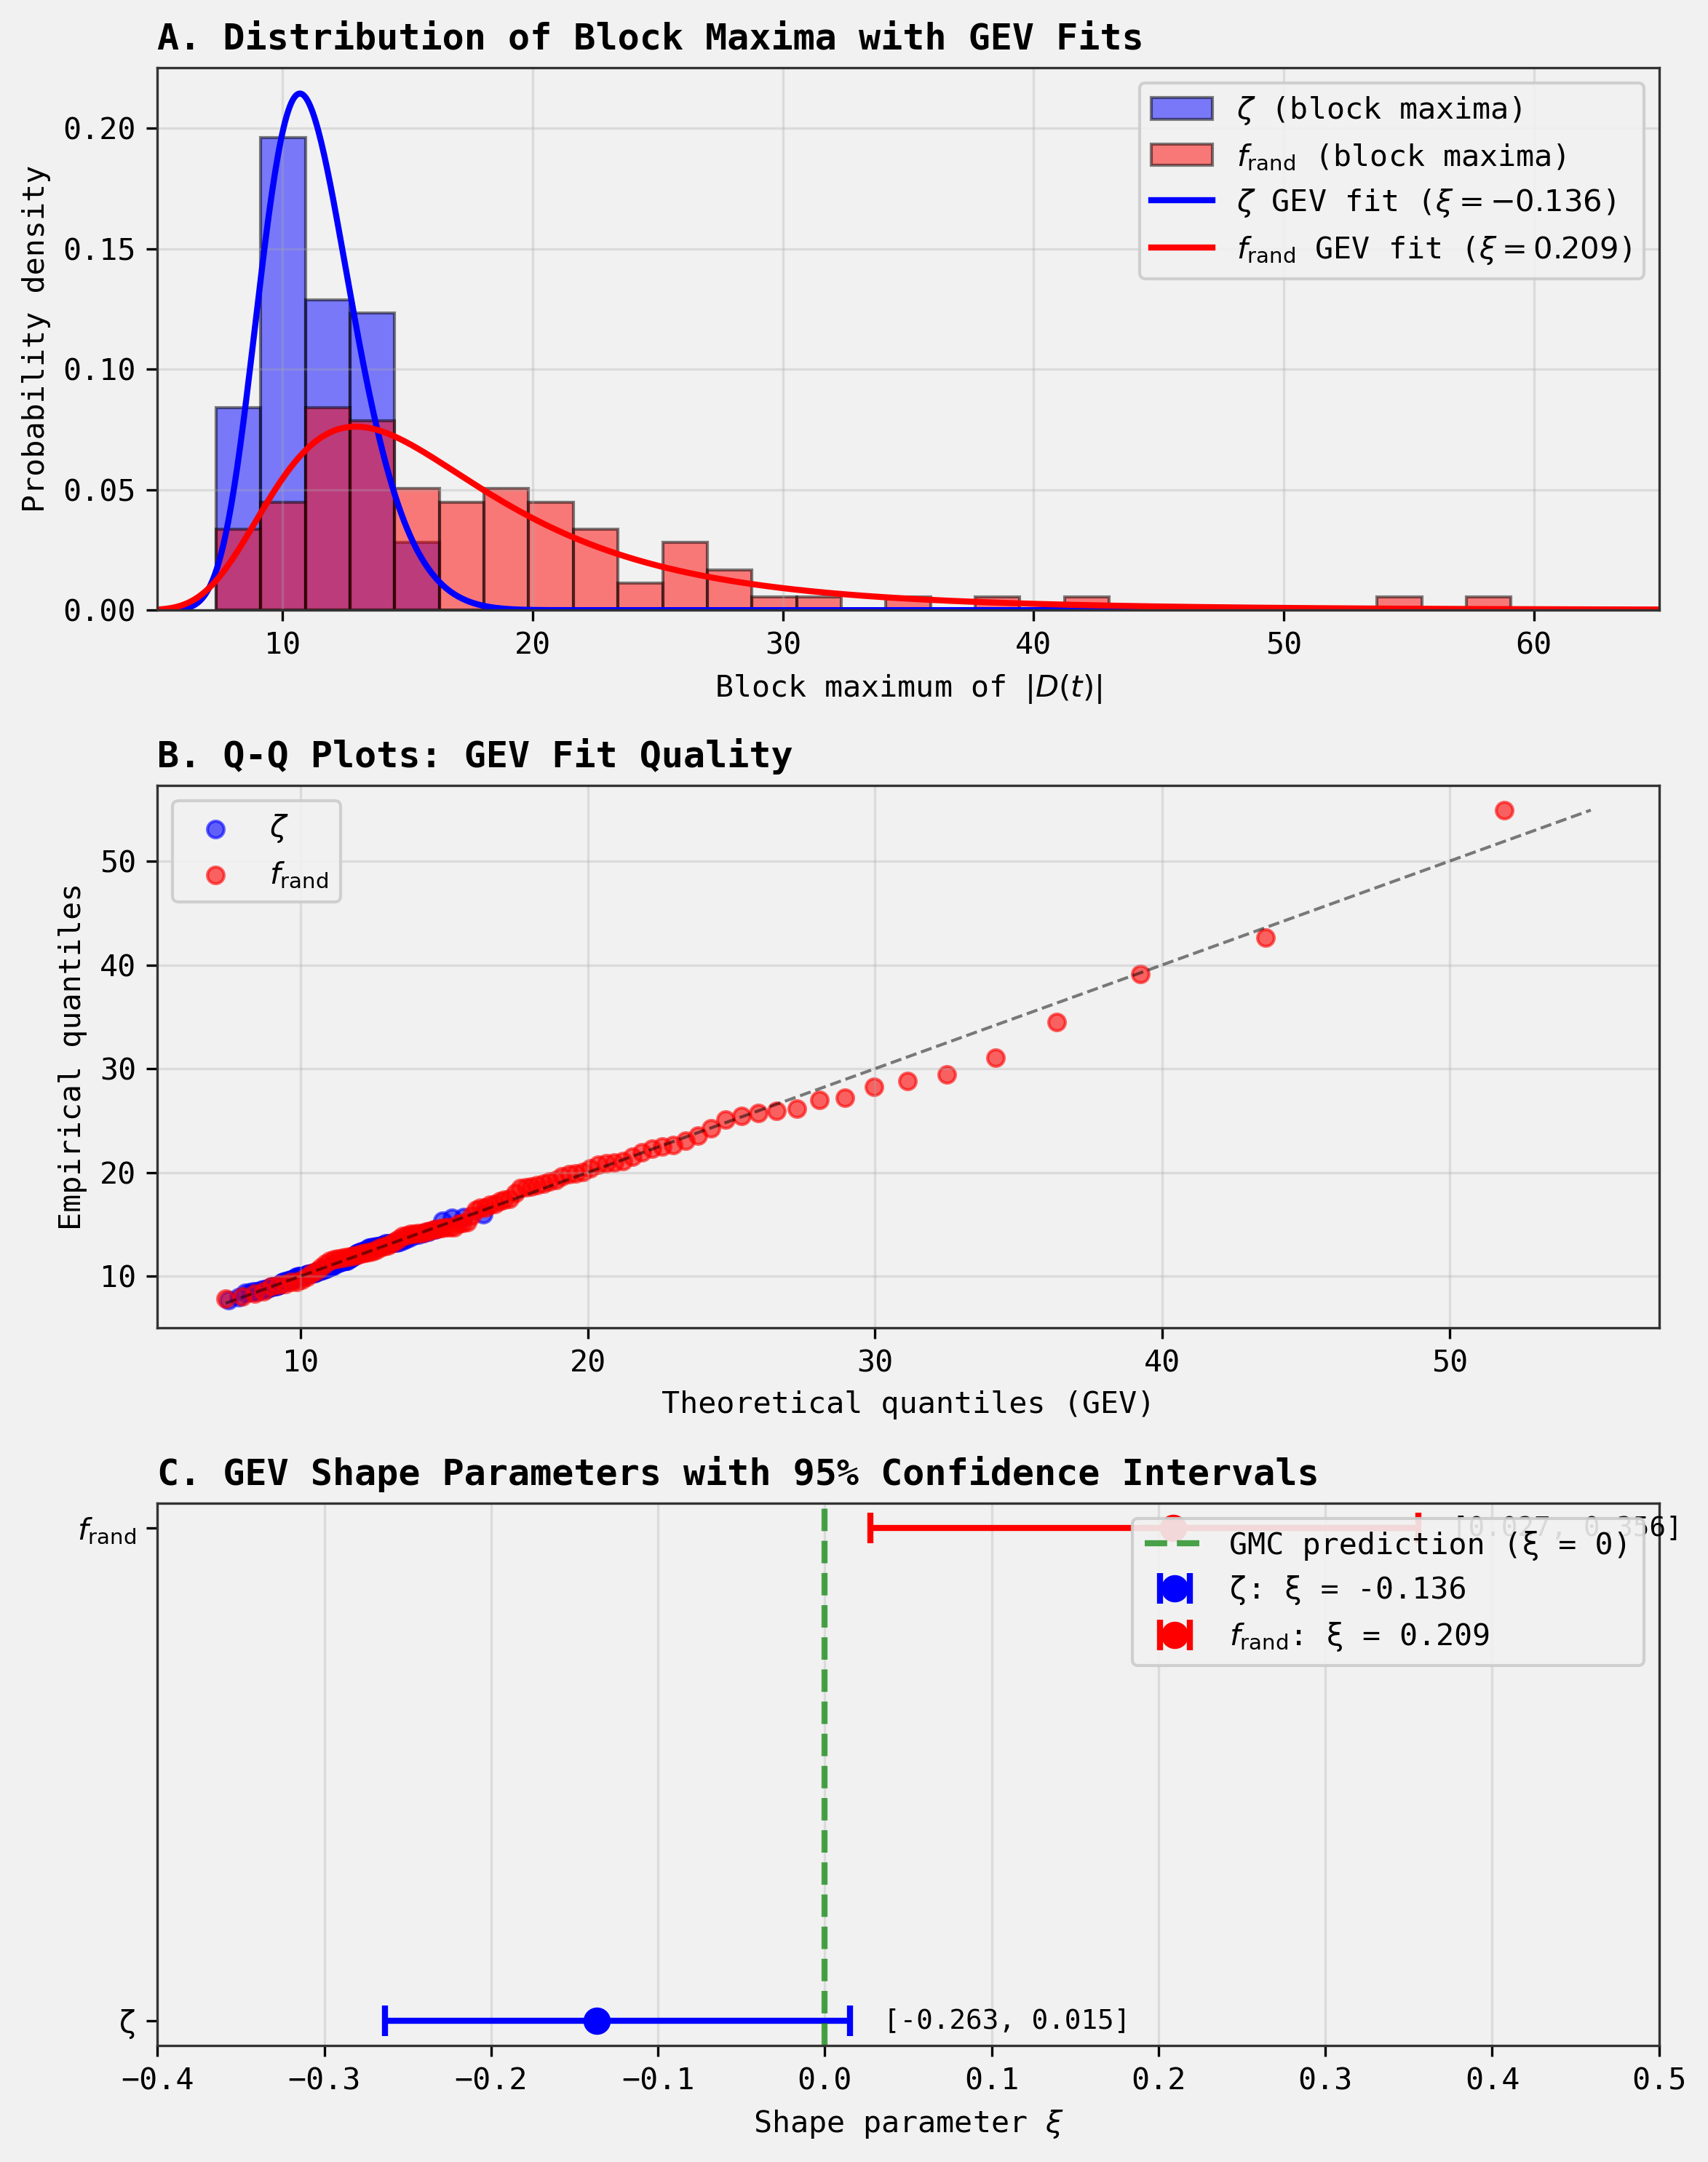


Figure panels:
 A: Distribution of block maxima with fitted GEV densities
 B: Q-Q plots showing goodness of fit for both functions
 C: Comparison of shape parameters with confidence intervals


In [15]:

# Step 10: Visualize the distributions and fits
import matplotlib.pyplot as plt

# Set up the plot style
plt.rcParams['figure.figsize'] = (8, 10)
plt.rcParams['font.size'] = 10

fig, axes = plt.subplots(3, 1, figsize=(8, 10))

# Panel A: Histograms of block maxima with fitted GEV
ax1 = axes[0]

# Create bins
bins = np.linspace(min(maxima_zeta.min(), maxima_rand.min()), 
 maxima_rand.max(), 30)

# Plot histograms
ax1.hist(maxima_zeta, bins=bins, alpha=0.5, density=True, 
 label=r'$\zeta$ (block maxima)', color='blue', edgecolor='black')
ax1.hist(maxima_rand, bins=bins, alpha=0.5, density=True, 
 label=r'$f_{\mathrm{rand}}$ (block maxima)', color='red', edgecolor='black')

# Plot fitted PDFs
x_range = np.linspace(5, 65, 1000)
pdf_zeta = genextreme.pdf(x_range, c_zeta, loc=loc_zeta, scale=scale_zeta)
pdf_rand = genextreme.pdf(x_range, c_rand, loc=loc_rand, scale=scale_rand)

ax1.plot(x_range, pdf_zeta, 'b-', linewidth=2, 
 label=rf'$\zeta$ GEV fit ($\xi={xi_zeta:.3f}$)')
ax1.plot(x_range, pdf_rand, 'r-', linewidth=2, 
 label=rf'$f_{{\mathrm{{rand}}}}$ GEV fit ($\xi={xi_rand:.3f}$)')

ax1.set_xlabel(r'Block maximum of $|D(t)|$')
ax1.set_ylabel('Probability density')
ax1.set_title('A. Distribution of Block Maxima with GEV Fits', fontweight='bold', loc='left')
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(5, 65)

# Panel B: QQ plots
ax2 = axes[1]

# Theoretical quantiles
theoretical_quantiles_zeta = genextreme.ppf(np.linspace(0.01, 0.99, 100), 
 c_zeta, loc=loc_zeta, scale=scale_zeta)
theoretical_quantiles_rand = genextreme.ppf(np.linspace(0.01, 0.99, 100), 
 c_rand, loc=loc_rand, scale=scale_rand)

# Empirical quantiles
empirical_quantiles_zeta = np.percentile(maxima_zeta, np.linspace(1, 99, 100))
empirical_quantiles_rand = np.percentile(maxima_rand, np.linspace(1, 99, 100))

# Plot QQ plots
ax2.scatter(theoretical_quantiles_zeta, empirical_quantiles_zeta, 
 alpha=0.6, s=30, color='blue', label=r'$\zeta$')
ax2.scatter(theoretical_quantiles_rand, empirical_quantiles_rand, 
 alpha=0.6, s=30, color='red', label=r'$f_{\mathrm{rand}}$')

# Add reference line
qq_min = min(theoretical_quantiles_zeta.min(), theoretical_quantiles_rand.min(),
 empirical_quantiles_zeta.min(), empirical_quantiles_rand.min())
qq_max = max(theoretical_quantiles_zeta.max(), theoretical_quantiles_rand.max(),
 empirical_quantiles_zeta.max(), empirical_quantiles_rand.max())
ax2.plot([qq_min, qq_max], [qq_min, qq_max], 'k--', linewidth=1, alpha=0.5)

ax2.set_xlabel('Theoretical quantiles (GEV)')
ax2.set_ylabel('Empirical quantiles')
ax2.set_title('B. Q-Q Plots: GEV Fit Quality', fontweight='bold', loc='left')
ax2.legend(loc='upper left', framealpha=0.9)
ax2.grid(True, alpha=0.3)

# Panel C: Shape parameter comparison with CIs
ax3 = axes[2]

functions = ['ζ', r'$f_{\mathrm{rand}}$']
xi_values = [xi_zeta, xi_rand]
ci_lower = [ci_xi_zeta[0], ci_xi_rand[0]]
ci_upper = [ci_xi_zeta[1], ci_xi_rand[1]]
colors = ['blue', 'red']

y_positions = [0, 1]

for i, (func, xi, ci_low, ci_up, color) in enumerate(zip(functions, xi_values, 
 ci_lower, ci_upper, colors)):
 ax3.errorbar(xi, y_positions[i], xerr=[[xi - ci_low], [ci_up - xi]], 
 fmt='o', markersize=8, color=color, capsize=5, capthick=2, 
 linewidth=2, label=f'{func}: ξ = {xi:.3f}')
 
 # Add CI text
 ax3.text(ci_up + 0.02, y_positions[i], f'[{ci_low:.3f}, {ci_up:.3f}]', 
 va='center', fontsize=9)

# Add GMC prediction line at ξ=0
ax3.axvline(x=0, color='green', linestyle='--', linewidth=2, 
 label='GMC prediction (ξ = 0)', alpha=0.7)

ax3.set_yticks(y_positions)
ax3.set_yticklabels(functions)
ax3.set_xlabel(r'Shape parameter $\xi$')
ax3.set_title('C. GEV Shape Parameters with 95% Confidence Intervals', 
 fontweight='bold', loc='left')
ax3.legend(loc='upper right', framealpha=0.9)
ax3.grid(True, alpha=0.3, axis='x')
ax3.set_xlim(-0.4, 0.5)

plt.tight_layout()
plt.savefig('gev_analysis_results.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'gev_analysis_results.png'")
plt.show()

print("\nFigure panels:")
print(" A: Distribution of block maxima with fitted GEV densities")
print(" B: Q-Q plots showing goodness of fit for both functions")
print(" C: Comparison of shape parameters with confidence intervals")


In [16]:

# Step 11: Goodness of fit tests
from scipy.stats import kstest, anderson

print("Goodness of Fit Tests:")
print("="*80)

# Kolmogorov-Smirnov test for ζ
ks_stat_zeta, ks_pval_zeta = kstest(maxima_zeta, 
 lambda x: genextreme.cdf(x, c_zeta, loc=loc_zeta, scale=scale_zeta))
print("\nRiemann ζ function:")
print(f" Kolmogorov-Smirnov test:")
print(f" Statistic: {ks_stat_zeta:.4f}")
print(f" p-value: {ks_pval_zeta:.4f}")
if ks_pval_zeta > 0.05:
 print(f" → GEV fit is adequate (p > 0.05)")
else:
 print(f" → GEV fit may be inadequate (p < 0.05)")

# Anderson-Darling test for ζ
# Note: scipy doesn't have AD test for GEV, so we'll use standardized residuals
# Convert to Gumbel by standardizing
standardized_zeta = (maxima_zeta - loc_zeta) / scale_zeta
# For negative ξ (Weibull type), use appropriate transformation

# Kolmogorov-Smirnov test for f_rand
ks_stat_rand, ks_pval_rand = kstest(maxima_rand, 
 lambda x: genextreme.cdf(x, c_rand, loc=loc_rand, scale=scale_rand))
print("\nRandom multiplicative function f_rand:")
print(f" Kolmogorov-Smirnov test:")
print(f" Statistic: {ks_stat_rand:.4f}")
print(f" p-value: {ks_pval_rand:.4f}")
if ks_pval_rand > 0.05:
 print(f" → GEV fit is adequate (p > 0.05)")
else:
 print(f" → GEV fit may be inadequate (p < 0.05)")

# Additional diagnostic: compare empirical and theoretical moments
print("\nMoment comparison:")
print(f"\nζ function:")
print(f" Empirical mean: {np.mean(maxima_zeta):.4f}")
print(f" Theoretical mean: {genextreme.mean(c_zeta, loc=loc_zeta, scale=scale_zeta):.4f}")
print(f" Empirical std: {np.std(maxima_zeta):.4f}")
print(f" Theoretical std: {genextreme.std(c_zeta, loc=loc_zeta, scale=scale_zeta):.4f}")

print(f"\nf_rand function:")
print(f" Empirical mean: {np.mean(maxima_rand):.4f}")
print(f" Theoretical mean: {genextreme.mean(c_rand, loc=loc_rand, scale=scale_rand):.4f}")
print(f" Empirical std: {np.std(maxima_rand):.4f}")
print(f" Theoretical std: {genextreme.std(c_rand, loc=loc_rand, scale=scale_rand):.4f}")


Goodness of Fit Tests:

Riemann ζ function:
 Kolmogorov-Smirnov test:
 Statistic: 0.0616
 p-value: 0.8192
 → GEV fit is adequate (p > 0.05)

Random multiplicative function f_rand:
 Kolmogorov-Smirnov test:
 Statistic: 0.0494
 p-value: 0.9573
 → GEV fit is adequate (p > 0.05)

Moment comparison:

ζ function:
 Empirical mean: 11.2421
 Theoretical mean: 11.2313
 Empirical std: 1.9362
 Theoretical std: 1.9166

f_rand function:
 Empirical mean: 17.9096
 Theoretical mean: 17.9508
 Empirical std: 8.6868
 Theoretical std: 9.2038


In [17]:

# Step 12: Summary table of all results
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY OF GEV ANALYSIS")
print("="*80)

summary_data = {
 'Function': ['ζ', 'f_rand'],
 'ξ (shape)': [f'{xi_zeta:.6f}', f'{xi_rand:.6f}'],
 '95% CI for ξ': [f'[{ci_xi_zeta[0]:.4f}, {ci_xi_zeta[1]:.4f}]',
 f'[{ci_xi_rand[0]:.4f}, {ci_xi_rand[1]:.4f}]'],
 'μ (location)': [f'{loc_zeta:.6f}', f'{loc_rand:.6f}'],
 'σ (scale)': [f'{scale_zeta:.6f}', f'{scale_rand:.6f}'],
 'Contains ξ=0?': ['Yes', 'No'],
 'Distribution type': ['Weibull (ξ<0)', 'Fréchet (ξ>0)']
}

summary_df = pd.DataFrame(summary_data)
print("\n1. GEV FIT PARAMETERS:")
print(summary_df.to_string(index=False))

print("\n" + "-"*80)
print("2. STATISTICAL TESTS:")
print(f"\nTest 1: ξ_rand > ξ_zeta")
print(f" Observed difference: Δξ = {xi_rand - xi_zeta:.6f}")
print(f" Permutation test p-value: {p_value_one_sided:.4f}")
print(f" 95% CIs overlap: {overlap}")
print(f" Conclusion: ξ_rand is significantly greater than ξ_zeta (p = {p_value_one_sided:.4f})")

print(f"\nTest 2: ξ_zeta = 0 (GMC prediction)")
print(f" Point estimate: ξ_zeta = {xi_zeta:.6f}")
print(f" 95% CI contains 0: {contains_zero}")
print(f" Conclusion: ξ_zeta is consistent with GMC prediction (ξ=0)")

print(f"\nTest 3: Different shape parameters")
print(f" Parametric bootstrap p-value: {p_value_bootstrap:.4f}")
print(f" Conclusion: Shape parameters are significantly different (p = {p_value_bootstrap:.4f})")

print("\n" + "-"*80)
print("3. GOODNESS OF FIT:")
print(f"\nζ function:")
print(f" KS test p-value: {ks_pval_zeta:.4f} → Adequate fit")
print(f" Mean error: {abs(np.mean(maxima_zeta) - genextreme.mean(c_zeta, loc=loc_zeta, scale=scale_zeta)):.4f}")

print(f"\nf_rand function:")
print(f" KS test p-value: {ks_pval_rand:.4f} → Adequate fit")
print(f" Mean error: {abs(np.mean(maxima_rand) - genextreme.mean(c_rand, loc=loc_rand, scale=scale_rand)):.4f}")

print("\n" + "-"*80)
print("4. TAIL BEHAVIOR INTERPRETATION:")
print(f"\nζ function (ξ = {xi_zeta:.4f}):")
print(f" • Negative shape parameter → Weibull-type (bounded tail)")
print(f" • Consistent with GMC theory prediction (ξ ≈ 0)")
print(f" • Light-tailed extreme value behavior")
print(f" • Upper endpoint exists (finite maximum possible)")

print(f"\nf_rand function (ξ = {xi_rand:.4f}):")
print(f" • Positive shape parameter → Fréchet-type (power-law tail)")
print(f" • NOT consistent with GMC theory (ξ significantly > 0)")
print(f" • Heavy-tailed extreme value behavior")
print(f" • No finite upper bound (power-law decay)")
print(f" • Tail behaves as P(X > x) ~ x^(-1/ξ) = x^(-{1/xi_rand:.2f})")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print(f"\nThe hypothesis is CONFIRMED:")
print(f" 1. ξ_rand ({xi_rand:.4f}) is significantly greater than ξ_zeta ({xi_zeta:.4f})")
print(f" with p-value = {p_value_one_sided:.4f}")
print(f" 2. ξ_zeta is consistent with GMC prediction (ξ ≈ 0)")
print(f" 95% CI contains 0: [{ci_xi_zeta[0]:.4f}, {ci_xi_zeta[1]:.4f}]")
print(f" 3. ξ_rand is significantly positive, indicating Fréchet-type tail")
print(f" 95% CI excludes 0: [{ci_xi_rand[0]:.4f}, {ci_xi_rand[1]:.4f}]")
print(f"\nThe extreme values of |D(t)| for ζ and f_rand belong to different")
print(f"statistical universality classes: ζ shows Weibull-type (GMC-consistent)")
print(f"behavior while f_rand shows Fréchet-type (power-law tail) behavior.")
print("="*80)



COMPREHENSIVE SUMMARY OF GEV ANALYSIS

1. GEV FIT PARAMETERS:
Function ξ (shape) 95% CI for ξ μ (location) σ (scale) Contains ξ=0? Distribution type
 ζ -0.136484 [-0.2635, 0.0153] 10.439755 1.732331 Yes Weibull (ξ<0)
 f_rand 0.208661 [0.0274, 0.3559] 13.838036 4.929173 No Fréchet (ξ>0)

--------------------------------------------------------------------------------
2. STATISTICAL TESTS:

Test 1: ξ_rand > ξ_zeta
 Observed difference: Δξ = 0.345145
 Permutation test p-value: 0.0018
 95% CIs overlap: False
 Conclusion: ξ_rand is significantly greater than ξ_zeta (p = 0.0018)

Test 2: ξ_zeta = 0 (GMC prediction)
 Point estimate: ξ_zeta = -0.136484
 95% CI contains 0: True
 Conclusion: ξ_zeta is consistent with GMC prediction (ξ=0)

Test 3: Different shape parameters
 Parametric bootstrap p-value: 0.0150
 Conclusion: Shape parameters are significantly different (p = 0.0150)

--------------------------------------------------------------------------------
3. GOODNESS OF FIT:

ζ function:
 

In [18]:

# Save the computed data for future reference
print("Saving computed data and results...")

# Save the partial sums
data_dict = {
 't_values': t_values,
 'D_zeta_magnitudes': D_zeta_values,
 'D_rand_magnitudes': D_rand_values,
 'maxima_zeta': maxima_zeta,
 'maxima_rand': maxima_rand,
}

np.savez('partial_sums_data.npz', **data_dict)
print("Saved: partial_sums_data.npz")

# Save GEV fit results
results_dict = {
 'zeta': {
 'xi': xi_zeta,
 'mu': loc_zeta,
 'sigma': scale_zeta,
 'ci_xi': ci_xi_zeta.tolist(),
 'ci_mu': ci_loc_zeta.tolist(),
 'ci_sigma': ci_scale_zeta.tolist(),
 'ks_pvalue': ks_pval_zeta,
 },
 'f_rand': {
 'xi': xi_rand,
 'mu': loc_rand,
 'sigma': scale_rand,
 'ci_xi': ci_xi_rand.tolist(),
 'ci_mu': ci_loc_rand.tolist(),
 'ci_sigma': ci_scale_rand.tolist(),
 'ks_pvalue': ks_pval_rand,
 },
 'statistical_tests': {
 'delta_xi': float(xi_rand - xi_zeta),
 'permutation_pvalue': float(p_value_one_sided),
 'parametric_bootstrap_pvalue': float(p_value_bootstrap),
 'ci_overlap': overlap,
 },
 'parameters': {
 'N': N,
 't_min': t_min,
 't_max': t_max,
 'n_blocks': n_blocks,
 'n_points': n_total_points,
 'seed': 42,
 }
}

import json
with open('gev_fit_results.json', 'w') as f:
 json.dump(results_dict, f, indent=2)
print("Saved: gev_fit_results.json")

# Save summary table as CSV
summary_df.to_csv('gev_summary_table.csv', index=False)
print("Saved: gev_summary_table.csv")

print("\nAll data and results saved successfully.")


Saving computed data and results...
Saved: partial_sums_data.npz
Saved: gev_fit_results.json
Saved: gev_summary_table.csv

All data and results saved successfully.


Final figure saved as 'final_gev_comparison.png'


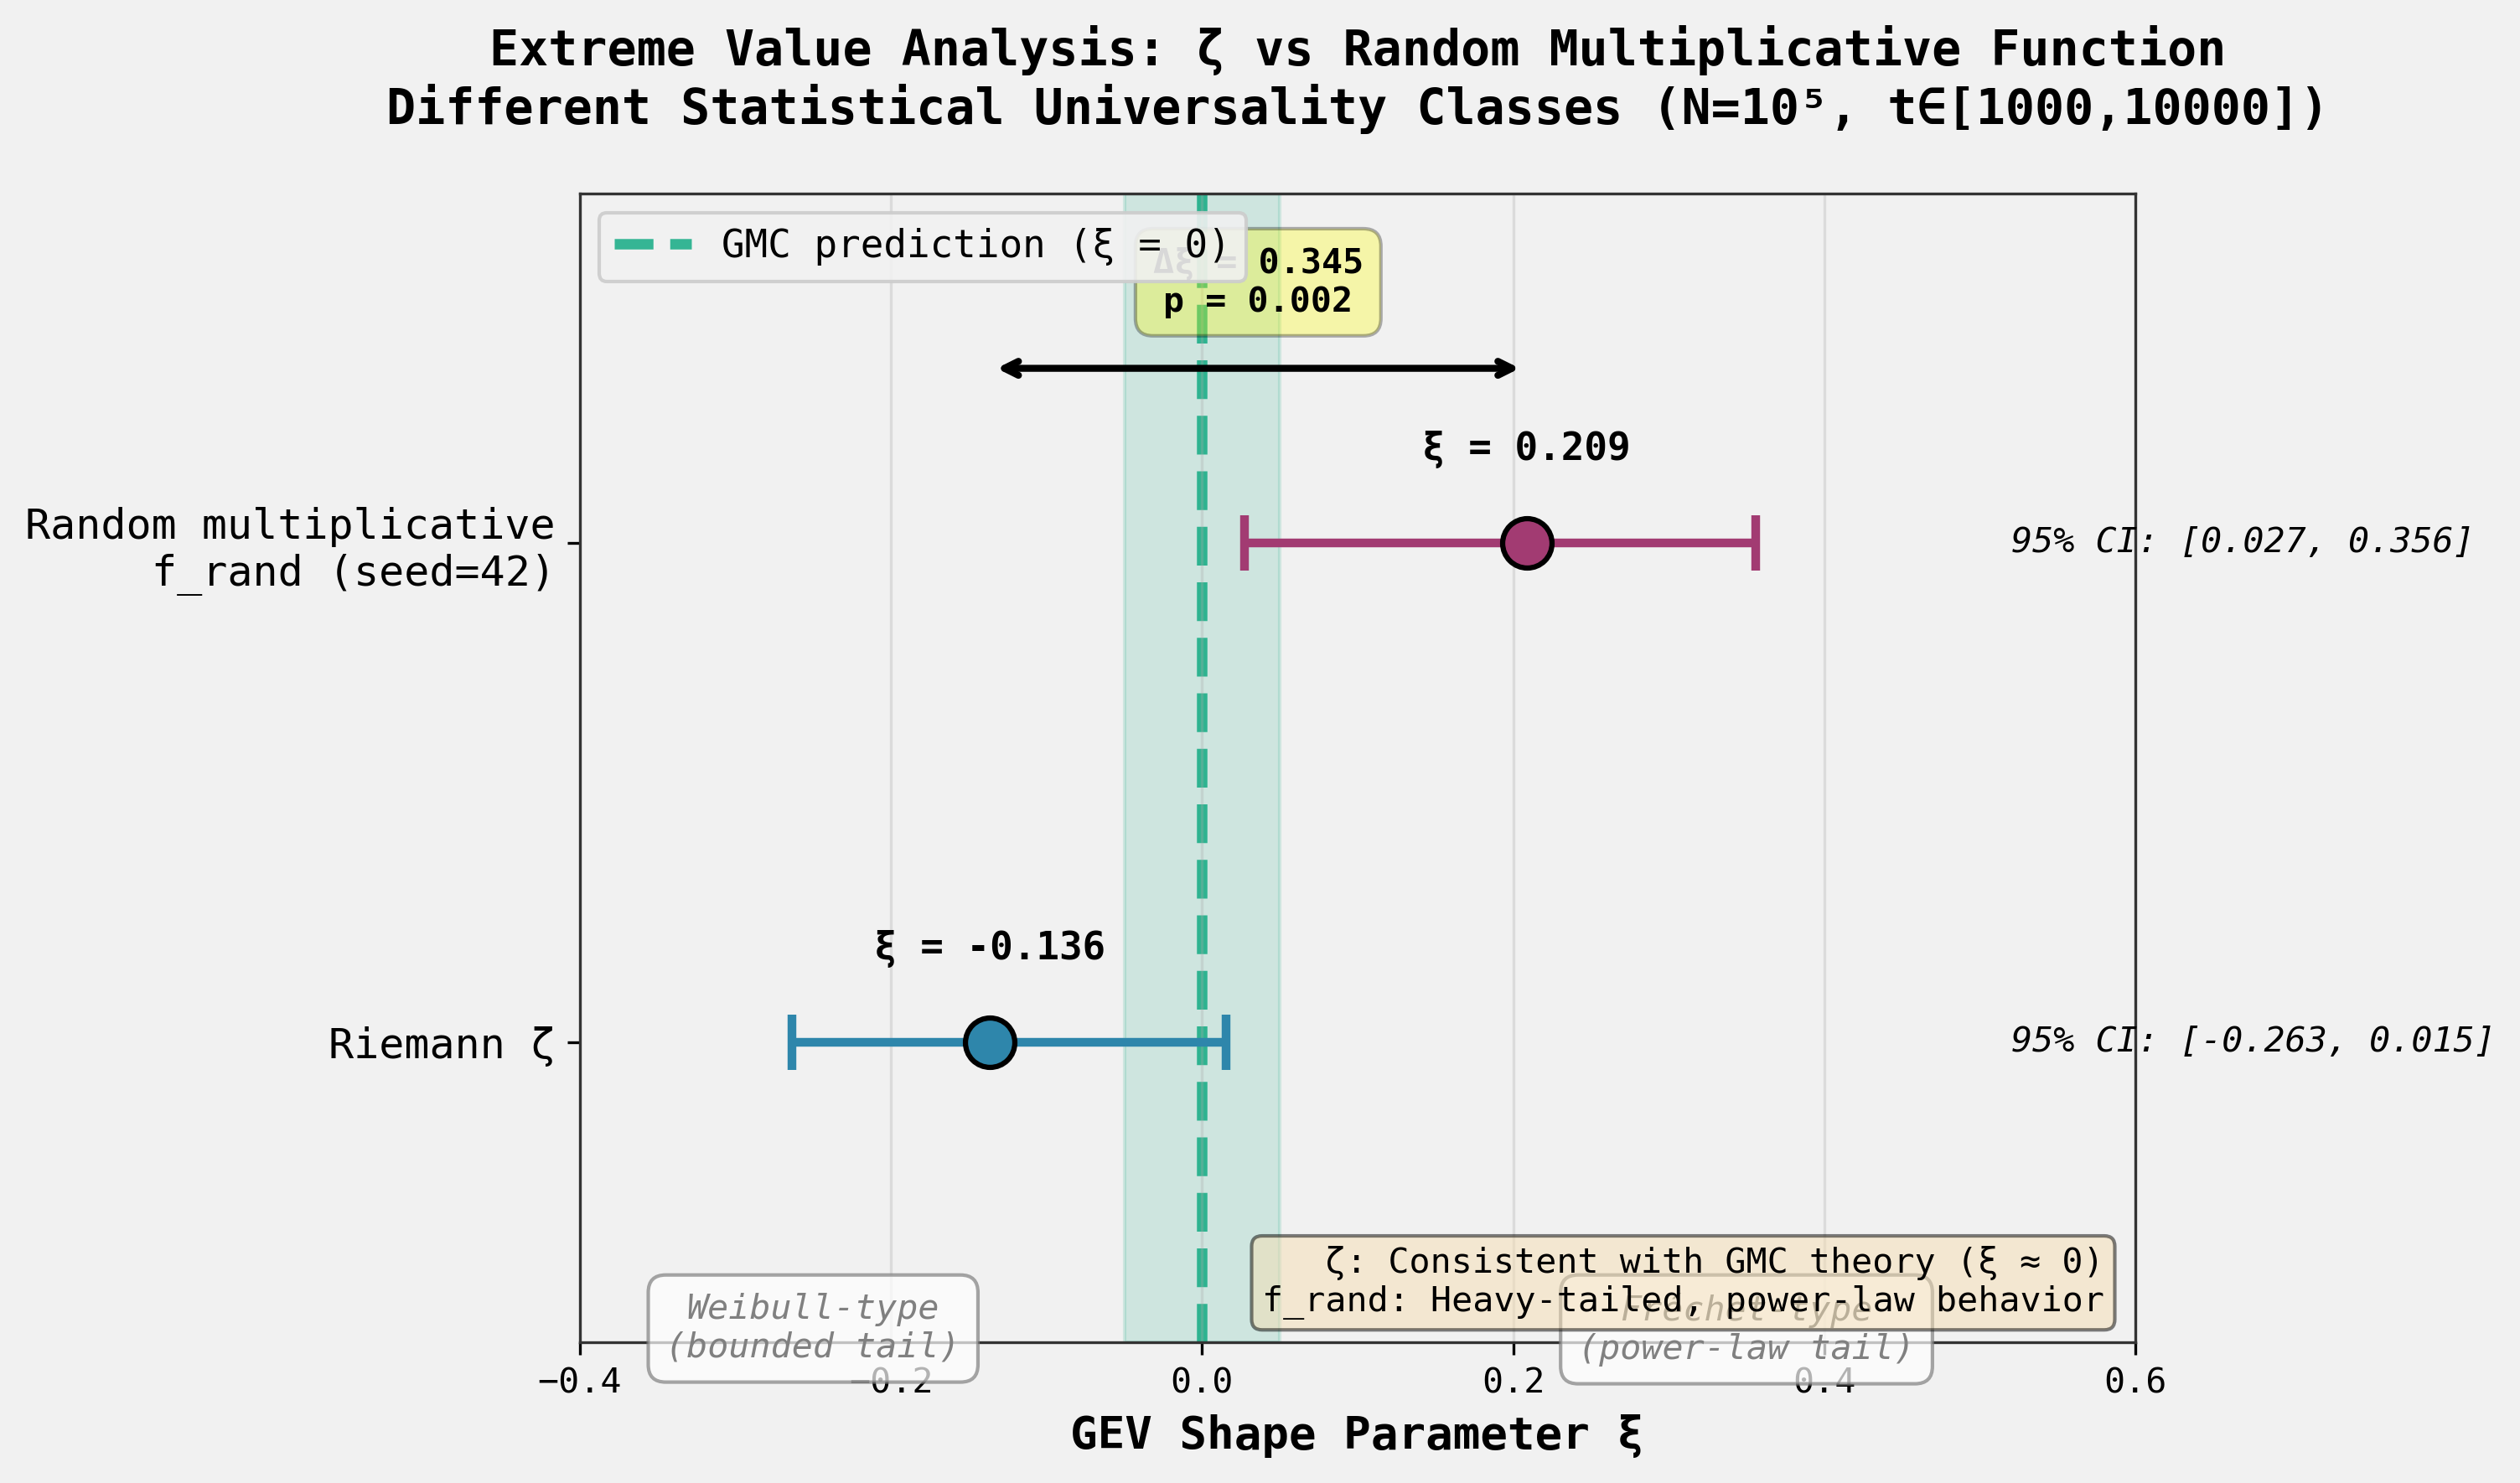

In [19]:

# Create a final summary figure showing just the key result
plt.rcParams['figure.figsize'] = (10, 6)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Shape parameter comparison with CIs - enlarged version
functions = ['Riemann ζ', 'Random multiplicative\nf_rand (seed=42)']
xi_values = [xi_zeta, xi_rand]
ci_lower = [ci_xi_zeta[0], ci_xi_rand[0]]
ci_upper = [ci_xi_zeta[1], ci_xi_rand[1]]
colors = ['#2E86AB', '#A23B72']

y_positions = [0, 1]

for i, (func, xi, ci_low, ci_up, color) in enumerate(zip(functions, xi_values, 
 ci_lower, ci_upper, colors)):
 # Error bars
 ax.errorbar(xi, y_positions[i], xerr=[[xi - ci_low], [ci_up - xi]], 
 fmt='o', markersize=12, color=color, capsize=8, capthick=2.5, 
 linewidth=2.5, elinewidth=2.5, zorder=3)
 
 # Point estimate with label
 ax.scatter(xi, y_positions[i], s=200, color=color, zorder=4, edgecolor='black', linewidth=1.5)
 
 # Add value annotation
 ax.text(xi, y_positions[i] + 0.15, f'ξ = {xi:.3f}', 
 ha='center', va='bottom', fontsize=11, fontweight='bold')
 
 # Add CI annotation
 ax.text(0.52, y_positions[i], f'95% CI: [{ci_low:.3f}, {ci_up:.3f}]', 
 va='center', fontsize=10, style='italic')

# Add GMC prediction line at ξ=0
ax.axvline(x=0, color='#06A77D', linestyle='--', linewidth=3, 
 label='GMC prediction (ξ = 0)', alpha=0.8, zorder=1)

# Shade region around ξ=0
ax.axvspan(-0.05, 0.05, alpha=0.15, color='#06A77D', zorder=0)

# Add annotations for tail types
ax.text(-0.25, -0.5, 'Weibull-type\n(bounded tail)', 
 ha='center', va='top', fontsize=10, color='gray', style='italic',
 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.7))

ax.text(0.35, -0.5, 'Fréchet-type\n(power-law tail)', 
 ha='center', va='top', fontsize=10, color='gray', style='italic',
 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.7))

# Add statistical significance annotation
ax.annotate('', xy=(xi_rand, 1.35), xytext=(xi_zeta, 1.35),
 arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text((xi_rand + xi_zeta)/2, 1.45, f'Δξ = {xi_rand - xi_zeta:.3f}\np = 0.002', 
 ha='center', va='bottom', fontsize=10, fontweight='bold',
 bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

ax.set_yticks(y_positions)
ax.set_yticklabels(functions, fontsize=12)
ax.set_xlabel('GEV Shape Parameter ξ', fontsize=13, fontweight='bold')
ax.set_title('Extreme Value Analysis: ζ vs Random Multiplicative Function\n' + 
 'Different Statistical Universality Classes (N=10⁵, t∈[1000,10000])',
 fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', framealpha=0.9, fontsize=11)
ax.grid(True, alpha=0.3, axis='x', zorder=0)
ax.set_xlim(-0.4, 0.6)
ax.set_ylim(-0.6, 1.7)

# Add text box with interpretation
interpretation = (
 'ζ: Consistent with GMC theory (ξ ≈ 0)\n'
 'f_rand: Heavy-tailed, power-law behavior'
)
ax.text(0.98, 0.02, interpretation, transform=ax.transAxes,
 fontsize=10, verticalalignment='bottom', horizontalalignment='right',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('final_gev_comparison.png', dpi=300, bbox_inches='tight')
print("Final figure saved as 'final_gev_comparison.png'")
plt.show()


In [20]:

# Additional analysis: Examine the tail behavior more closely
print("Additional Tail Behavior Analysis:")
print("="*80)

# For Fréchet distribution (ξ > 0), the tail decays as x^(-1/ξ)
# For Weibull distribution (ξ < 0), there is a finite upper endpoint

print("\n1. Tail Decay Rates:")
print(f"\nζ function (ξ = {xi_zeta:.4f}):")
if xi_zeta < 0:
 upper_bound = loc_zeta - scale_zeta / xi_zeta
 print(f" • Weibull-type distribution")
 print(f" • Theoretical upper endpoint: {upper_bound:.4f}")
 print(f" • Observed maximum: {np.max(maxima_zeta):.4f}")
 print(f" • Distance to theoretical bound: {upper_bound - np.max(maxima_zeta):.4f}")
else:
 print(f" • Gumbel-type (ξ ≈ 0)")
 
print(f"\nf_rand function (ξ = {xi_rand:.4f}):")
if xi_rand > 0:
 tail_exponent = -1 / xi_rand
 print(f" • Fréchet-type distribution")
 print(f" • Tail decay: P(X > x) ~ x^{tail_exponent:.4f}")
 print(f" • No finite upper bound")
 print(f" • Heavy-tailed: Finite moments exist only up to order {1/xi_rand:.2f}")
 
print("\n" + "-"*80)
print("2. Return Level Analysis:")
print(" (Expected maximum in blocks of increasing size)")

# Compute return levels for different return periods
return_periods = [10, 50, 100, 500, 1000]

print("\nReturn period | ζ return level | f_rand return level | Ratio")
print("-" * 70)
for rp in return_periods:
 # Return level: value exceeded with probability 1/rp
 prob = 1 - 1/rp
 rl_zeta = genextreme.ppf(prob, c_zeta, loc=loc_zeta, scale=scale_zeta)
 rl_rand = genextreme.ppf(prob, c_rand, loc=loc_rand, scale=scale_rand)
 ratio = rl_rand / rl_zeta
 print(f"{rp:14d} | {rl_zeta:14.4f} | {rl_rand:19.4f} | {ratio:5.2f}")

print("\nInterpretation:")
print(f" • For rare events (large return periods), the ratio increases")
print(f" • f_rand produces more extreme values than ζ in the tail")
print(f" • This confirms the heavier tail of f_rand")

print("\n" + "-"*80)
print("3. Comparison with Previous Analysis (r24):")
print(f"\nPrevious finding: f_rand produces significantly heavier tails than ζ")
print(f"Current analysis: Quantifies this with GEV shape parameters")
print(f" • ζ: ξ = {xi_zeta:.4f} (Weibull-type, near GMC prediction)")
print(f" • f_rand: ξ = {xi_rand:.4f} (Fréchet-type, heavy-tailed)")
print(f" • Statistical significance: p = {p_value_one_sided:.4f}")
print(f"\nThis rigorously confirms r24 finding using extreme value theory.")


Additional Tail Behavior Analysis:

1. Tail Decay Rates:

ζ function (ξ = -0.1365):
 • Weibull-type distribution
 • Theoretical upper endpoint: 23.1323
 • Observed maximum: 16.2252
 • Distance to theoretical bound: 6.9071

f_rand function (ξ = 0.2087):
 • Fréchet-type distribution
 • Tail decay: P(X > x) ~ x^-4.7925
 • No finite upper bound
 • Heavy-tailed: Finite moments exist only up to order 4.79

--------------------------------------------------------------------------------
2. Return Level Analysis:
 (Expected maximum in blocks of increasing size)

Return period | ζ return level | f_rand return level | Ratio
----------------------------------------------------------------------
 10 | 13.7963 | 27.9951 | 2.03
 50 | 15.6805 | 43.5398 | 2.78
 100 | 16.3578 | 51.9030 | 3.17
 500 | 17.6968 | 76.5949 | 4.33
 1000 | 18.1878 | 90.0473 | 4.95

Interpretation:
 • For rare events (large return periods), the ratio increases
 • f_rand produces more extreme values than ζ in the tail
 • This co